In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
from ipywidgets import interactive, FloatSlider, IntSlider, Dropdown, Button, Output
from IPython.display import display
import os

# Load datasets
#file_path = '78B_AT90(ohm.m).csv'
file_path = '58_AT90(ohm.m).csv'
data = pd.read_csv(file_path, delimiter=';')
sorted_data = data.sort_values(by='Z (well)')
sorted_depth = sorted_data['Z (well)']
sorted_resistivity = sorted_data['AT90 (ohm.m)']
# Load MT data
#mt_file = 'MT2D_Near 58.csv'
mt_file = 'A1_Near 58.csv'
mt_data = pd.read_csv(mt_file, delimiter=';')
sorted_mt_data = mt_data.sort_values(by='Z')
sorted_new_depth = sorted_mt_data['Z']
sorted_mt_resistivity = sorted_mt_data['inv (ohm.m)']

# Extract file names for title
well_name = os.path.splitext(file_path)[0]  # Remove .csv extension
mt_name = os.path.splitext(mt_file)[0]      # Remove .csv extension

# Apply log10 transformation
log_resistivity = np.log10(sorted_resistivity)
log_mt_resistivity = np.log10(sorted_mt_resistivity)

# load data porosity
porosity_file = 'effective_porosity_split_78B.csv'
porosity_data = pd.read_csv(porosity_file, delimiter=';')
sorted_porosity_data = porosity_data.sort_values(by='DEPTH')
sorted_porosity_depth = sorted_porosity_data['DEPTH']
sorted_ndphi = sorted_porosity_data['PHIE']  # Total porosity

### RESAMPLED

In [12]:
# ============== MASKING + MEAN/STD OF POROSITY NDPHI AT MT DEPTH POINTS ==============

# Step 1: Find common depth range (overlap between MT and NDPHI)
mt_depth_arr  = sorted_new_depth.values.astype(float)
ndphi_depth_arr = sorted_porosity_depth.values.astype(float)
ndphi_arr       = sorted_ndphi.values.astype(float)

common_min = max(mt_depth_arr.min(), ndphi_depth_arr.min())
common_max = min(mt_depth_arr.max(), ndphi_depth_arr.max())

print(f"MT depth range   : {mt_depth_arr.min():.1f} – {mt_depth_arr.max():.1f} m")
print(f"NDPHI depth range : {ndphi_depth_arr.min():.1f} – {ndphi_depth_arr.max():.1f} m")
print(f"Common range     : {common_min:.1f} – {common_max:.1f} m")

# Mask both datasets to the common depth range  
mt_mask   = (mt_depth_arr   >= common_min) & (mt_depth_arr   <= common_max)
ndphi_mask = (ndphi_depth_arr >= common_min) & (ndphi_depth_arr <= common_max)

mt_depth_masked   = mt_depth_arr[mt_mask]
mt_res_masked     = sorted_mt_data['inv (ohm.m)'].values[mt_mask]

ndphi_depth_masked = ndphi_depth_arr[ndphi_mask]
ndphi_masked       = ndphi_arr[ndphi_mask]

print(f"\nMT points after masking   : {mt_mask.sum()}")
print(f"NDPHI points after masking : {ndphi_mask.sum()}")

# Step 2 & 3: For each MT depth point, collect NDPHI values within ±half_step,
# then compute mean and std (uncertainty)
half_step = np.diff(mt_depth_masked).mean() / 2  # half the average MT depth step
print(f"\nHalf MT depth step used as window: ±{half_step:.2f} m")

ndphi_mean_at_mt = np.full(len(mt_depth_masked), np.nan)
ndphi_std_at_mt  = np.full(len(mt_depth_masked), np.nan)
ndphi_count_at_mt = np.zeros(len(mt_depth_masked), dtype=int)

for i, z in enumerate(mt_depth_masked):
    in_window = (ndphi_depth_masked >= z - half_step) & (ndphi_depth_masked <= z + half_step)
    vals = ndphi_masked[in_window]
    if len(vals) > 0:
        ndphi_mean_at_mt[i] = vals.mean()
        ndphi_std_at_mt[i]  = vals.std(ddof=0)   # population std; use ddof=1 for sample std
        ndphi_count_at_mt[i] = len(vals)

# Build result DataFrame
ndphi_at_mt_df = pd.DataFrame({
    'depth_m'        : mt_depth_masked,
    'mt_res_ohmm'    : mt_res_masked,
    'ndphi_mean'      : ndphi_mean_at_mt,
    'ndphi_std'       : ndphi_std_at_mt,
    'n_ndphi_samples' : ndphi_count_at_mt
})

n_nan = ndphi_at_mt_df['ndphi_mean'].isna().sum()
print(f"\nResult shape   : {ndphi_at_mt_df.shape}")
print(f"MT points with no NDPHI in window: {n_nan}  (consider widening half_step if > 0)")
print(ndphi_at_mt_df.head(10).to_string(index=False))

# Optional: drop rows where no NDPHI was found
ndphi_at_mt_clean = ndphi_at_mt_df.dropna(subset=['ndphi_mean']).reset_index(drop=True)
print(f"\nClean result (NaN rows dropped): {len(ndphi_at_mt_clean)} points")


MT depth range   : -1047.2 – 1687.5 m
NDPHI depth range : -922.2 – 782.0 m
Common range     : -922.2 – 782.0 m

MT points after masking   : 13
NDPHI points after masking : 11154

Half MT depth step used as window: ±62.30 m

Result shape   : (13, 5)
MT points with no NDPHI in window: 0  (consider widening half_step if > 0)
 depth_m  mt_res_ohmm  ndphi_mean  ndphi_std  n_ndphi_samples
 -753.57       169.61    0.038019   0.011845              818
 -508.83       151.97    0.043818   0.018362              785
 -304.88       134.72    0.034847   0.009910              817
 -134.92       119.51    0.035285   0.013339              818
    6.71       106.64    0.037279   0.013796              817
  124.74        95.98    0.038662   0.013589              818
  229.00        86.72    0.062894   0.026127              817
  327.36        78.10    0.065479   0.020788              818
  420.15        70.06    0.056754   0.021769              818
  507.69        62.53    0.048560   0.024612            

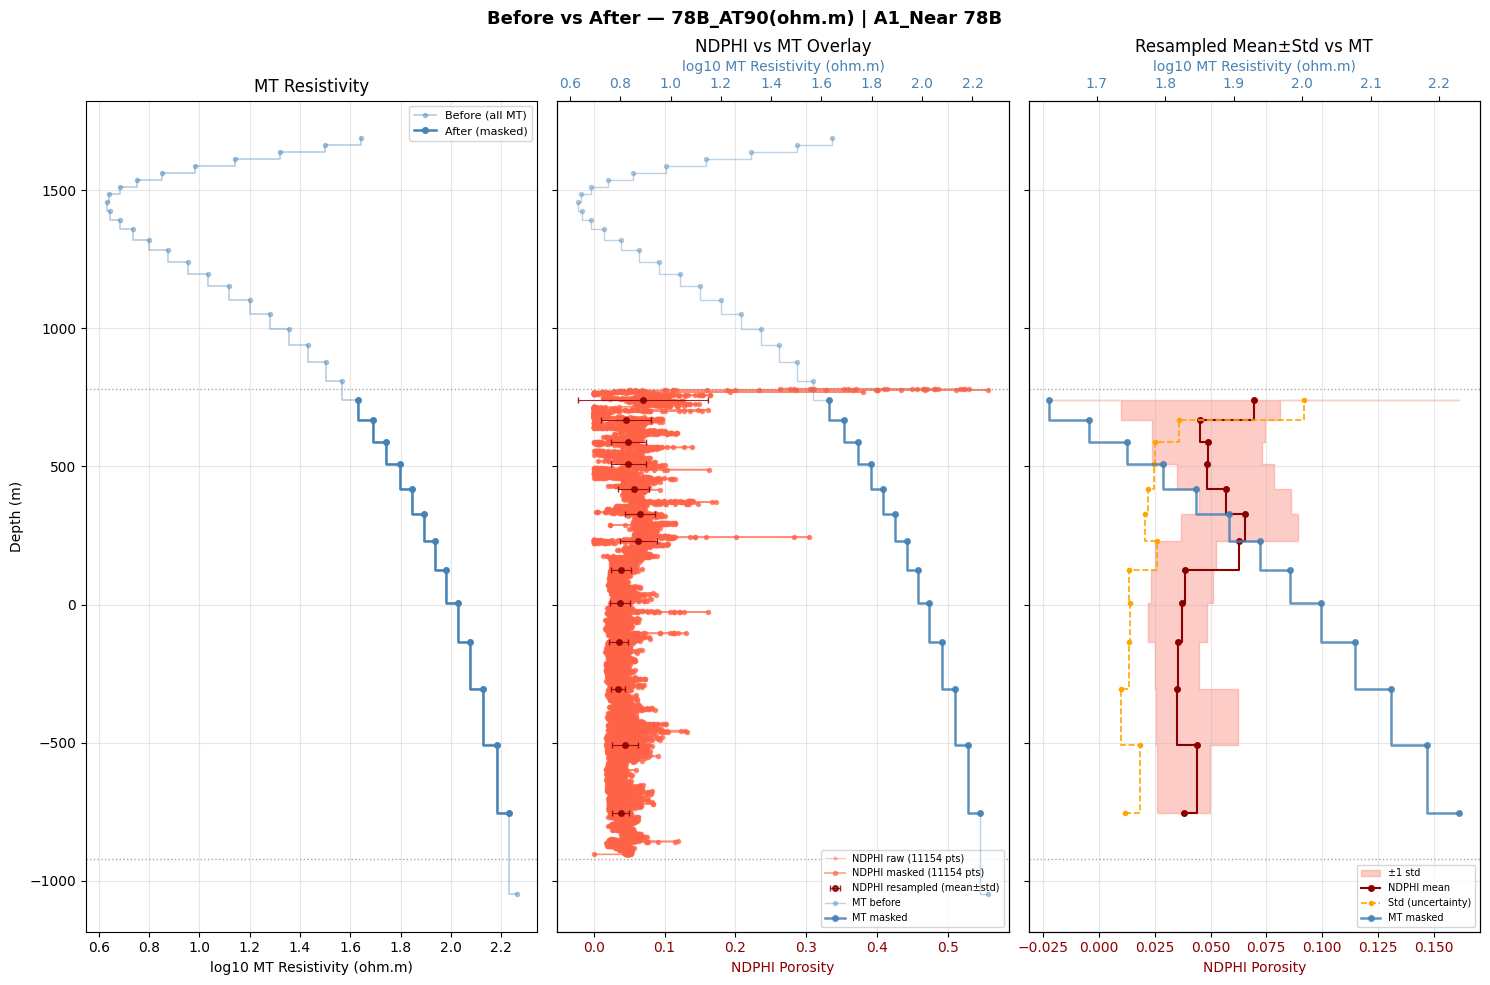

Saved: comparison_before_after.png


In [13]:
# ============== COMPARISON PLOT: BEFORE vs AFTER + MT OVERLAY (STEP + MARKERS) ==============

fig, axes = plt.subplots(1, 3, figsize=(15, 10), sharey=True)
fig.suptitle(f'Before vs After — {well_name} | {mt_name}', fontsize=13, fontweight='bold')

STEP = 'steps-post'

# ---------- Panel 1: MT Resistivity ----------
ax = axes[0]
ax.plot(np.log10(sorted_mt_data['inv (ohm.m)'].values), sorted_new_depth.values,
        color='steelblue', lw=1.2, alpha=0.4, drawstyle=STEP,
        marker='o', markersize=3, markevery=1, label='Before (all MT)')
ax.plot(np.log10(mt_res_masked), mt_depth_masked,
        color='steelblue', lw=1.8, drawstyle=STEP,
        marker='o', markersize=4, markevery=1, label='After (masked)')
ax.set_xlabel('log10 MT Resistivity (ohm.m)')
ax.set_ylabel('Depth (m)')
ax.set_title('MT Resistivity')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ---------- Panel 2: ndphi raw vs resampled + MT overlay ----------
ax = axes[1]
ax.plot(ndphi_arr, ndphi_depth_arr,
        color='tomato', lw=0.8, alpha=0.35, drawstyle=STEP,
        marker='o', markersize=2, markevery=1, label=f'NDPHI raw ({len(ndphi_depth_arr)} pts)')
ax.plot(ndphi_masked, ndphi_depth_masked,
        color='tomato', lw=1.2, alpha=0.6, drawstyle=STEP,
        marker='o', markersize=3, markevery=1, label=f'NDPHI masked ({ndphi_mask.sum()} pts)')
ax.errorbar(ndphi_mean_at_mt, mt_depth_masked,
            xerr=ndphi_std_at_mt,
            fmt='o', color='darkred', markersize=4, lw=1,
            capsize=2, elinewidth=0.8, alpha=0.85,
            label='NDPHI resampled (mean±std)')
ax.set_xlabel('NDPHI Porosity', color='darkred')
ax.tick_params(axis='x', labelcolor='darkred')
ax.set_title('NDPHI vs MT Overlay')
ax.grid(True, alpha=0.3)

ax2 = ax.twiny()
ax2.plot(np.log10(sorted_mt_data['inv (ohm.m)'].values), sorted_new_depth.values,
         color='steelblue', lw=1.0, alpha=0.35, drawstyle=STEP,
         marker='o', markersize=3, markevery=1, label='MT before')
ax2.plot(np.log10(mt_res_masked), mt_depth_masked,
         color='steelblue', lw=1.8, alpha=0.85, drawstyle=STEP,
         marker='o', markersize=4, markevery=1, label='MT masked')
ax2.set_xlabel('log10 MT Resistivity (ohm.m)', color='steelblue')
ax2.tick_params(axis='x', labelcolor='steelblue')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='lower right')

# ---------- Panel 3: Resampled mean±std + MT overlay ----------
ax = axes[2]
ax.fill_betweenx(mt_depth_masked,
                 ndphi_mean_at_mt - ndphi_std_at_mt,
                 ndphi_mean_at_mt + ndphi_std_at_mt,
                 color='salmon', alpha=0.4, step='post', label='±1 std')
ax.plot(ndphi_mean_at_mt, mt_depth_masked,
        color='darkred', lw=1.5, drawstyle=STEP,
        marker='o', markersize=4, markevery=1, label='NDPHI mean')
ax.plot(ndphi_std_at_mt, mt_depth_masked,
        color='orange', lw=1.2, linestyle='--', drawstyle=STEP,
        marker='o', markersize=3, markevery=1, label='Std (uncertainty)')
ax.set_xlabel('NDPHI Porosity', color='darkred')
ax.tick_params(axis='x', labelcolor='darkred')
ax.set_title('Resampled Mean±Std vs MT')
ax.grid(True, alpha=0.3)

ax3 = ax.twiny()
ax3.plot(np.log10(mt_res_masked), mt_depth_masked,
         color='steelblue', lw=1.8, alpha=0.85, drawstyle=STEP,
         marker='o', markersize=4, markevery=1, label='MT masked')
ax3.set_xlabel('log10 MT Resistivity (ohm.m)', color='steelblue')
ax3.tick_params(axis='x', labelcolor='steelblue')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='lower right')

# Common depth range markers
for ax in axes:
    ax.axhline(common_min, color='gray', lw=1, linestyle=':', alpha=0.7)
    ax.axhline(common_max, color='gray', lw=1, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('comparison_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_before_after.png")


In [11]:
# ============== EXPORT RESULTS ==============

# Export resampled data (with NaN rows dropped)
out_csv = f'resampled_HTNP_at_MT_{well_name}.csv'
htnp_at_mt_clean.to_csv(out_csv, index=False, sep=';')
print(f"Saved: {out_csv}")
print(htnp_at_mt_clean.head())


Saved: resampled_HTNP_at_MT_78B_AT90(ohm.m).csv
   depth_m  mt_res_ohmm  htnp_mean  htnp_std  n_htnp_samples
0  -753.57       169.61   0.016919  0.013065             818
1  -508.83       151.97   0.009021  0.010482             776
2  -304.88       134.72   0.007885  0.009705             818
3  -134.92       119.51   0.006235  0.012193             818
4     6.71       106.64   0.013305  0.013066             817


### 25m RESAMPLED

In [14]:
# ============== MASKING + RESAMPLING TO 25m FIXED STEP ==============
from scipy.interpolate import interp1d

STEP_M = 25  # target depth step in meters

# Step 1: Common depth range
mt_depth_arr   = sorted_new_depth.values.astype(float)
ndphi_depth_arr = sorted_porosity_depth.values.astype(float)
ndphi_arr       = sorted_ndphi.values.astype(float)

common_min = max(mt_depth_arr.min(), ndphi_depth_arr.min())
common_max = min(mt_depth_arr.max(), ndphi_depth_arr.max())

print(f"MT depth range   : {mt_depth_arr.min():.1f} – {mt_depth_arr.max():.1f} m")
print(f"NDPHI depth range : {ndphi_depth_arr.min():.1f} – {ndphi_depth_arr.max():.1f} m")
print(f"Common range     : {common_min:.1f} – {common_max:.1f} m")

# Step 2: Mask both to common range
mt_mask   = (mt_depth_arr   >= common_min) & (mt_depth_arr   <= common_max)
ndphi_mask = (ndphi_depth_arr >= common_min) & (ndphi_depth_arr <= common_max)

mt_depth_masked   = mt_depth_arr[mt_mask]
mt_res_masked     = sorted_mt_data['inv (ohm.m)'].values[mt_mask]
ndphi_depth_masked = ndphi_depth_arr[ndphi_mask]
ndphi_masked       = ndphi_arr[ndphi_mask]

print(f"\nMT points after masking   : {mt_mask.sum()}")
print(f"NDPHI points after masking : {ndphi_mask.sum()}")

# Step 3: Build 25m regular grid
grid_depth = np.arange(common_min, common_max + STEP_M, STEP_M)
grid_depth = grid_depth[(grid_depth >= common_min) & (grid_depth <= common_max)]
half_step  = STEP_M / 2
print(f"\n25m grid: {grid_depth[0]:.1f} – {grid_depth[-1]:.1f} m  ({len(grid_depth)} points)")

# Step 4: Resample NDPHI — mean/std within each ±half_step window
ndphi_mean_25m = np.full(len(grid_depth), np.nan)
ndphi_std_25m  = np.full(len(grid_depth), np.nan)
ndphi_n_25m    = np.zeros(len(grid_depth), dtype=int)

for i, z in enumerate(grid_depth):
    hw = (ndphi_depth_masked >= z - half_step) & (ndphi_depth_masked <= z + half_step)
    vals = ndphi_masked[hw]
    if len(vals) > 0:
        ndphi_mean_25m[i] = vals.mean()
        ndphi_std_25m[i]  = vals.std(ddof=0)
        ndphi_n_25m[i]    = len(vals)

# Step 5: Interpolate MT resistivity to 25m grid
# Sort MT by depth first to ensure monotonic input for interp1d
sort_idx      = np.argsort(mt_depth_masked)
mt_depth_sort = mt_depth_masked[sort_idx]
mt_res_sort   = mt_res_masked[sort_idx]

mt_interp_fn  = interp1d(mt_depth_sort, mt_res_sort, kind='linear', bounds_error=False,
                          fill_value=np.nan)
mt_res_25m    = mt_interp_fn(grid_depth)

print(f"MT interpolated to 25m grid — NaN outside range: "
      f"{np.isnan(mt_res_25m).sum()} pts")

# Step 6: Build result DataFrame
resampled_25m = pd.DataFrame({
    'depth_m'        : grid_depth,
    'mt_res_ohmm'    : mt_res_25m,        # interpolated
    'ndphi_mean'      : ndphi_mean_25m,     # resampled mean
    'ndphi_std'       : ndphi_std_25m,      # resampled std
    'n_ndphi_samples' : ndphi_n_25m,
})

n_nan_ndphi = resampled_25m['ndphi_mean'].isna().sum()
n_nan_mt   = resampled_25m['mt_res_ohmm'].isna().sum()
print(f"\nResult shape              : {resampled_25m.shape}")
print(f"Grid points no NDPHI       : {n_nan_ndphi}")
print(f"Grid points no MT         : {n_nan_mt}")

resampled_25m_clean = resampled_25m.dropna(subset=['ndphi_mean', 'mt_res_ohmm']).reset_index(drop=True)
print(f"Clean points (both valid) : {len(resampled_25m_clean)}")
print(resampled_25m_clean.head(10).to_string(index=False))

# Export
resampled_25m_clean.to_csv(f'resampled_1m_{well_name}.csv', index=False, sep=';')
print(f"\nSaved: resampled_25m_{well_name}.csv")


MT depth range   : -1047.2 – 1687.5 m
NDPHI depth range : -922.2 – 782.0 m
Common range     : -922.2 – 782.0 m

MT points after masking   : 13
NDPHI points after masking : 11154

25m grid: -922.2 – 777.8 m  (69 points)
MT interpolated to 25m grid — NaN outside range: 9 pts

Result shape              : (69, 5)
Grid points no NDPHI       : 2
Grid points no MT         : 9
Clean points (both valid) : 60
  depth_m  mt_res_ohmm  ndphi_mean  ndphi_std  n_ndphi_samples
-747.2091   169.151529    0.033387   0.008624              164
-722.2091   167.349616    0.035766   0.013533              164
-697.2091   165.547704    0.036304   0.011899              165
-672.2091   163.745792    0.038533   0.014577              164
-647.2091   161.943880    0.031924   0.009664              164
-622.2091   160.141967    0.029123   0.007273              164
-597.2091   158.340055    0.027800   0.007056              164
-572.2091   156.538143    0.031086   0.008718              164
-547.2091   154.736231    0.04

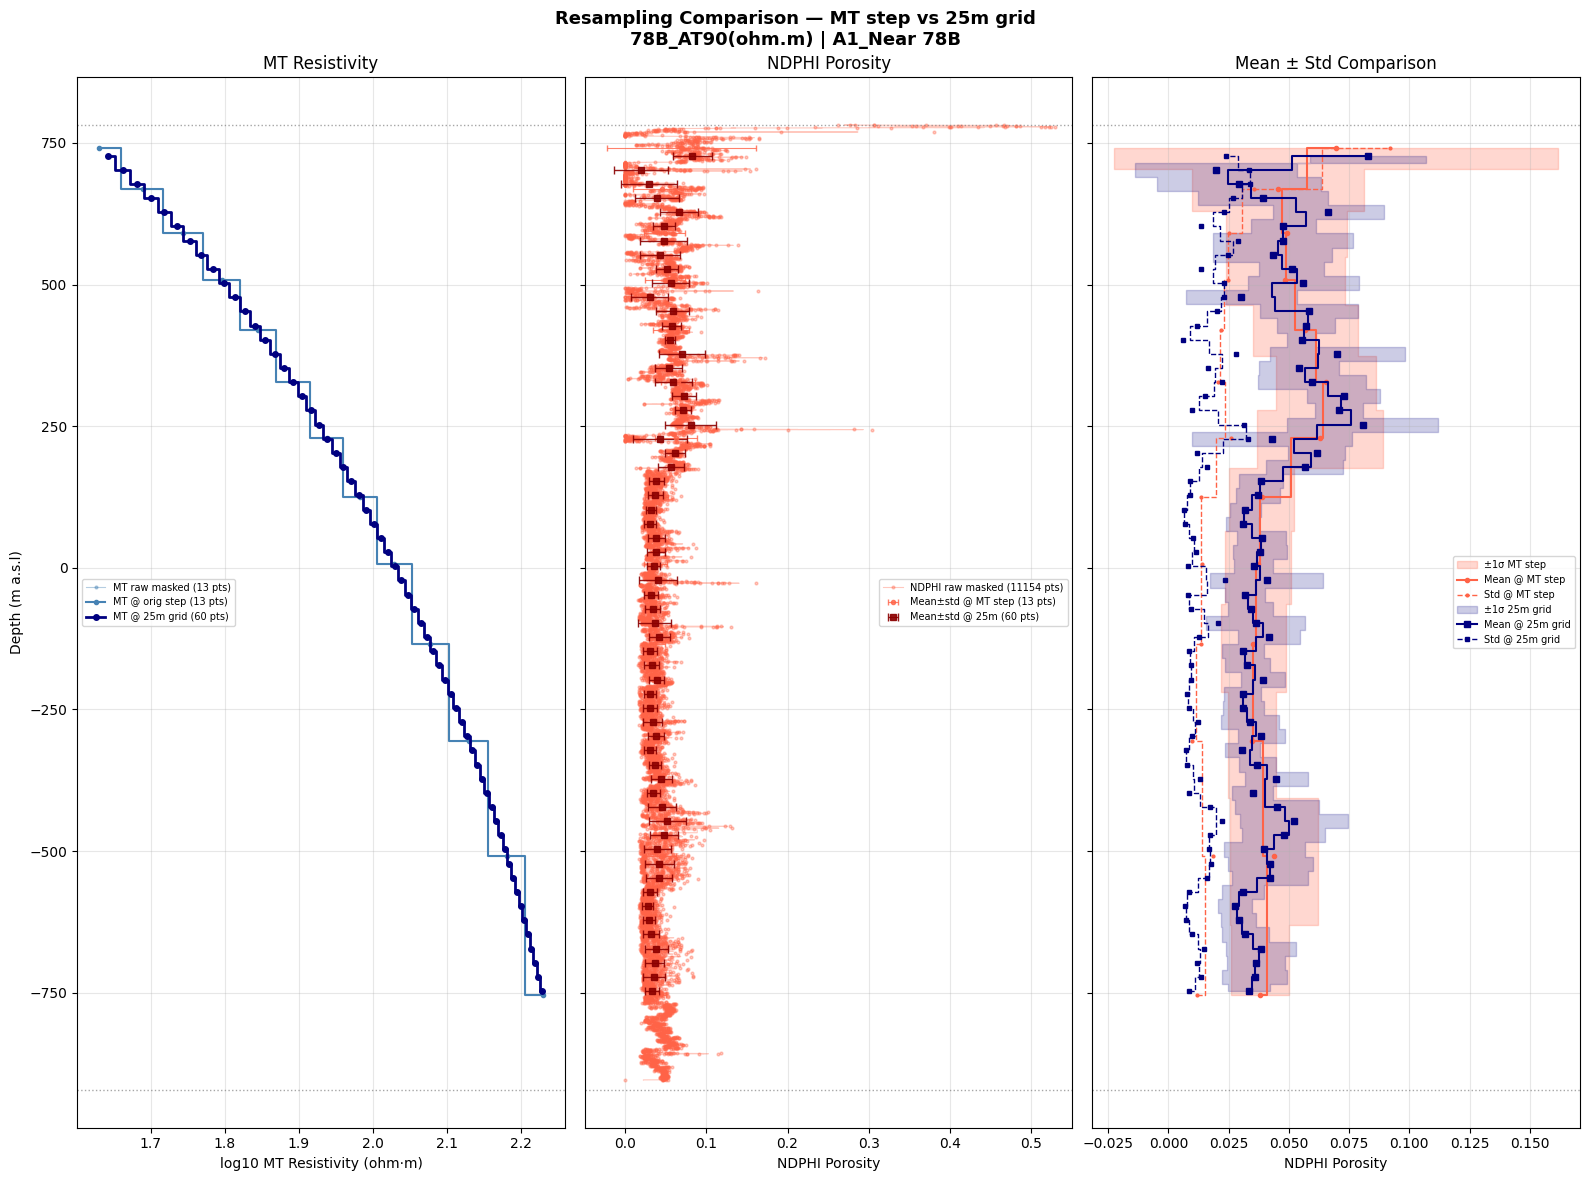

Saved: comparison_MTstep_vs_25m_78.png


In [15]:
# ============== COMPARISON PLOT: MT-step vs 25m resampled ==============

fig, axes = plt.subplots(1, 3, figsize=(16, 12), sharey=True)
fig.suptitle(f'Resampling Comparison — MT step vs 25m grid\n{well_name} | {mt_name}',
             fontsize=13, fontweight='bold')

STEP = 'steps-mid'

# ---------- Panel 1: MT Resistivity ----------
ax = axes[0]
# Raw MT (masked)
ax.plot(np.log10(mt_res_masked), mt_depth_masked,
        color='steelblue', lw=0.8, alpha=0.4, drawstyle=STEP,
        marker='o', markersize=2, label=f'MT raw masked ({len(mt_depth_masked)} pts)')
# MT at original MT-step (from ndphi_at_mt_clean)
ax.plot(np.log10(ndphi_at_mt_clean['mt_res_ohmm']), ndphi_at_mt_clean['depth_m'],
        color='steelblue', lw=1.5, drawstyle=STEP,
        marker='o', markersize=3, label=f'MT @ orig step ({len(ndphi_at_mt_clean)} pts)')
# MT at 25m grid
ax.plot(np.log10(resampled_25m_clean['mt_res_ohmm']), resampled_25m_clean['depth_m'],
        color='navy', lw=2, drawstyle=STEP,
        marker='o', markersize=4, label=f'MT @ 25m grid ({len(resampled_25m_clean)} pts)')

ax.set_xlabel('log10 MT Resistivity (ohm·m)')
ax.set_ylabel('Depth (m a.s.l)')
ax.set_title('MT Resistivity')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ---------- Panel 2: NDPHI porosity ----------
ax = axes[1]
# Raw NDPHI (masked)
ax.plot(ndphi_masked, ndphi_depth_masked,
        color='tomato', lw=0.8, alpha=0.35, drawstyle=STEP,
        marker='o', markersize=2, label=f'NDPHI raw masked ({len(ndphi_depth_masked)} pts)')
# MT-step resampled mean ± std
ax.errorbar(ndphi_at_mt_clean['ndphi_mean'], ndphi_at_mt_clean['depth_m'],
            xerr=ndphi_at_mt_clean['ndphi_std'],
            fmt='o', color='tomato', markersize=3, lw=1,
            capsize=2, elinewidth=0.8, alpha=0.8,
            label=f'Mean±std @ MT step ({len(ndphi_at_mt_clean)} pts)')
# 25m resampled mean ± std
ax.errorbar(resampled_25m_clean['ndphi_mean'], resampled_25m_clean['depth_m'],
            xerr=resampled_25m_clean['ndphi_std'],
            fmt='s', color='darkred', markersize=4, lw=1.2,
            capsize=3, elinewidth=1, alpha=0.9,
            label=f'Mean±std @ 25m ({len(resampled_25m_clean)} pts)')

ax.set_xlabel('NDPHI Porosity')
ax.set_title('NDPHI Porosity')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ---------- Panel 3: Std (uncertainty) comparison ----------
ax = axes[2]
# MT-step std
ax.fill_betweenx(ndphi_at_mt_clean['depth_m'],
                 ndphi_at_mt_clean['ndphi_mean'] - ndphi_at_mt_clean['ndphi_std'],
                 ndphi_at_mt_clean['ndphi_mean'] + ndphi_at_mt_clean['ndphi_std'],
                 color='tomato', alpha=0.25, step='mid', label='±1σ MT step')
ax.plot(ndphi_at_mt_clean['ndphi_mean'], ndphi_at_mt_clean['depth_m'],
        color='tomato', lw=1.5, drawstyle=STEP,
        marker='o', markersize=3, label='Mean @ MT step')
ax.plot(ndphi_at_mt_clean['ndphi_std'], ndphi_at_mt_clean['depth_m'],
        color='tomato', lw=1, linestyle='--', drawstyle=STEP,
        marker='o', markersize=2, label='Std @ MT step')

# 25m std
ax.fill_betweenx(resampled_25m_clean['depth_m'],
                 resampled_25m_clean['ndphi_mean'] - resampled_25m_clean['ndphi_std'],
                 resampled_25m_clean['ndphi_mean'] + resampled_25m_clean['ndphi_std'],
                 color='navy', alpha=0.2, step='mid', label='±1σ 25m grid')
ax.plot(resampled_25m_clean['ndphi_mean'], resampled_25m_clean['depth_m'],
        color='navy', lw=1.5, drawstyle=STEP,
        marker='s', markersize=4, label='Mean @ 25m grid')
ax.plot(resampled_25m_clean['ndphi_std'], resampled_25m_clean['depth_m'],
        color='navy', lw=1, linestyle='--', drawstyle=STEP,
        marker='s', markersize=3, label='Std @ 25m grid')

ax.set_xlabel('NDPHI Porosity')
ax.set_title('Mean ± Std Comparison')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Common depth range markers on all panels
for ax in axes:
    ax.axhline(common_min, color='gray', lw=1, linestyle=':', alpha=0.7)
    ax.axhline(common_max, color='gray', lw=1, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('comparison_MTstep_vs_25m_78.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_MTstep_vs_25m_78.png")


In [18]:
# ============== RE-RESAMPLE FROM 25m → 1m via LINEAR INTERP + GAUSSIAN SMOOTHING ==============
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
print("\n--- Gaussian Filter Smoothing: 25m → 1m ---")

# Step 7: Build 1m regular grid
depth_min_clean = resampled_25m_clean['depth_m'].min()
depth_max_clean = resampled_25m_clean['depth_m'].max()
grid_depth_1m   = np.arange(depth_min_clean, depth_max_clean + 1, 1.0)
print(f"1m grid: {grid_depth_1m[0]:.1f} – {grid_depth_1m[-1]:.1f} m  ({len(grid_depth_1m)} points)")

anchor_depth = resampled_25m_clean['depth_m'].values

# ── Smoothing sigma controls the Gaussian kernel width ────────────────────
# sigma is in units of 1m samples. sigma=5 → ~5m smoothing radius.
# Higher sigma = smoother; lower sigma = closer to raw linear interpolation.
SIGMA = 100

# ===========================================================================
# >>>  Set to True to apply Gaussian smoothing, False for linear only  <
# ===========================================================================
SMOOTH_MT    = False   # MT resistivity  — linear only by default
SMOOTH_NDPHI = True    # NDPHI mean      — Gaussian smoothed
SMOOTH_STD   = True    # NDPHI std       — Gaussian smoothed
# ===========================================================================

def interpolate_channel(y_train, label, apply_smooth=True, sigma=SIGMA):
    """
    1. Linear interpolation from 25m anchors onto 1m grid.
    2. Optionally apply gaussian_filter1d for smoothing.
    """
    interp_func  = interp1d(anchor_depth, y_train, kind='linear', fill_value='extrapolate')
    y_1m_linear  = interp_func(grid_depth_1m)

    if apply_smooth:
        y_1m_out = gaussian_filter1d(y_1m_linear, sigma=sigma)
        method   = f"linear → Gaussian (sigma={sigma})"
    else:
        y_1m_out = y_1m_linear
        method   = "linear only (no smoothing)"

    # Diagnostics
    max_residual = np.abs(interp_func(anchor_depth) - y_train).max()
    print(f"  [{label}] method          : {method}")
    print(f"  [{label}] max residual    : {max_residual:.6f}")
    return y_1m_out

# Step 8: Interpolate each channel
mt_1m    = interpolate_channel(resampled_25m_clean['mt_res_ohmm'].values, 'MT res',    apply_smooth=SMOOTH_MT)
ndphi_1m = interpolate_channel(resampled_25m_clean['ndphi_mean'].values,  'NDPHI mean',apply_smooth=SMOOTH_NDPHI)
std_1m   = interpolate_channel(resampled_25m_clean['ndphi_std'].values,   'NDPHI std', apply_smooth=SMOOTH_STD)

# Step 9: Build 1m DataFrame
resampled_1m = pd.DataFrame({
    'depth_m'     : grid_depth_1m,
    'mt_res_ohmm' : mt_1m,
    'ndphi_mean'  : ndphi_1m,
    'ndphi_std'   : std_1m,
})
resampled_1m_clean = resampled_1m.dropna(subset=['mt_res_ohmm', 'ndphi_mean']).reset_index(drop=True)
print(f"\nResult shape (1m) : {resampled_1m.shape}")
print(f"Clean 1m points   : {len(resampled_1m_clean)}")
print(resampled_1m_clean.head(10).to_string(index=False))

# Step 10: Export
resampled_25m_clean.to_csv(f'resampled_25m_{well_name}_78.csv', index=False, sep=';')
resampled_1m_clean.to_csv(f'resampled_1m_{well_name}_78.csv',   index=False, sep=';')
print(f"\nSaved: resampled_25m_{well_name}.csv")
print(f"Saved: resampled_1m_{well_name}.csv")


--- Gaussian Filter Smoothing: 25m → 1m ---
1m grid: -747.2 – 727.8 m  (1476 points)
  [MT res] method          : linear only (no smoothing)
  [MT res] max residual    : 0.000000
  [NDPHI mean] method          : linear → Gaussian (sigma=100)
  [NDPHI mean] max residual    : 0.000000
  [NDPHI std] method          : linear → Gaussian (sigma=100)
  [NDPHI std] max residual    : 0.000000

Result shape (1m) : (1476, 4)
Clean 1m points   : 1476
  depth_m  mt_res_ohmm  ndphi_mean  ndphi_std
-747.2091   169.151529    0.034663   0.011427
-746.2091   169.079452    0.034663   0.011427
-745.2091   169.007376    0.034663   0.011427
-744.2091   168.935299    0.034663   0.011427
-743.2091   168.863223    0.034663   0.011427
-742.2091   168.791146    0.034664   0.011427
-741.2091   168.719070    0.034664   0.011427
-740.2091   168.646993    0.034664   0.011427
-739.2091   168.574917    0.034665   0.011428
-738.2091   168.502840    0.034665   0.011428

Saved: resampled_25m_78B_AT90(ohm.m).csv
Saved: r

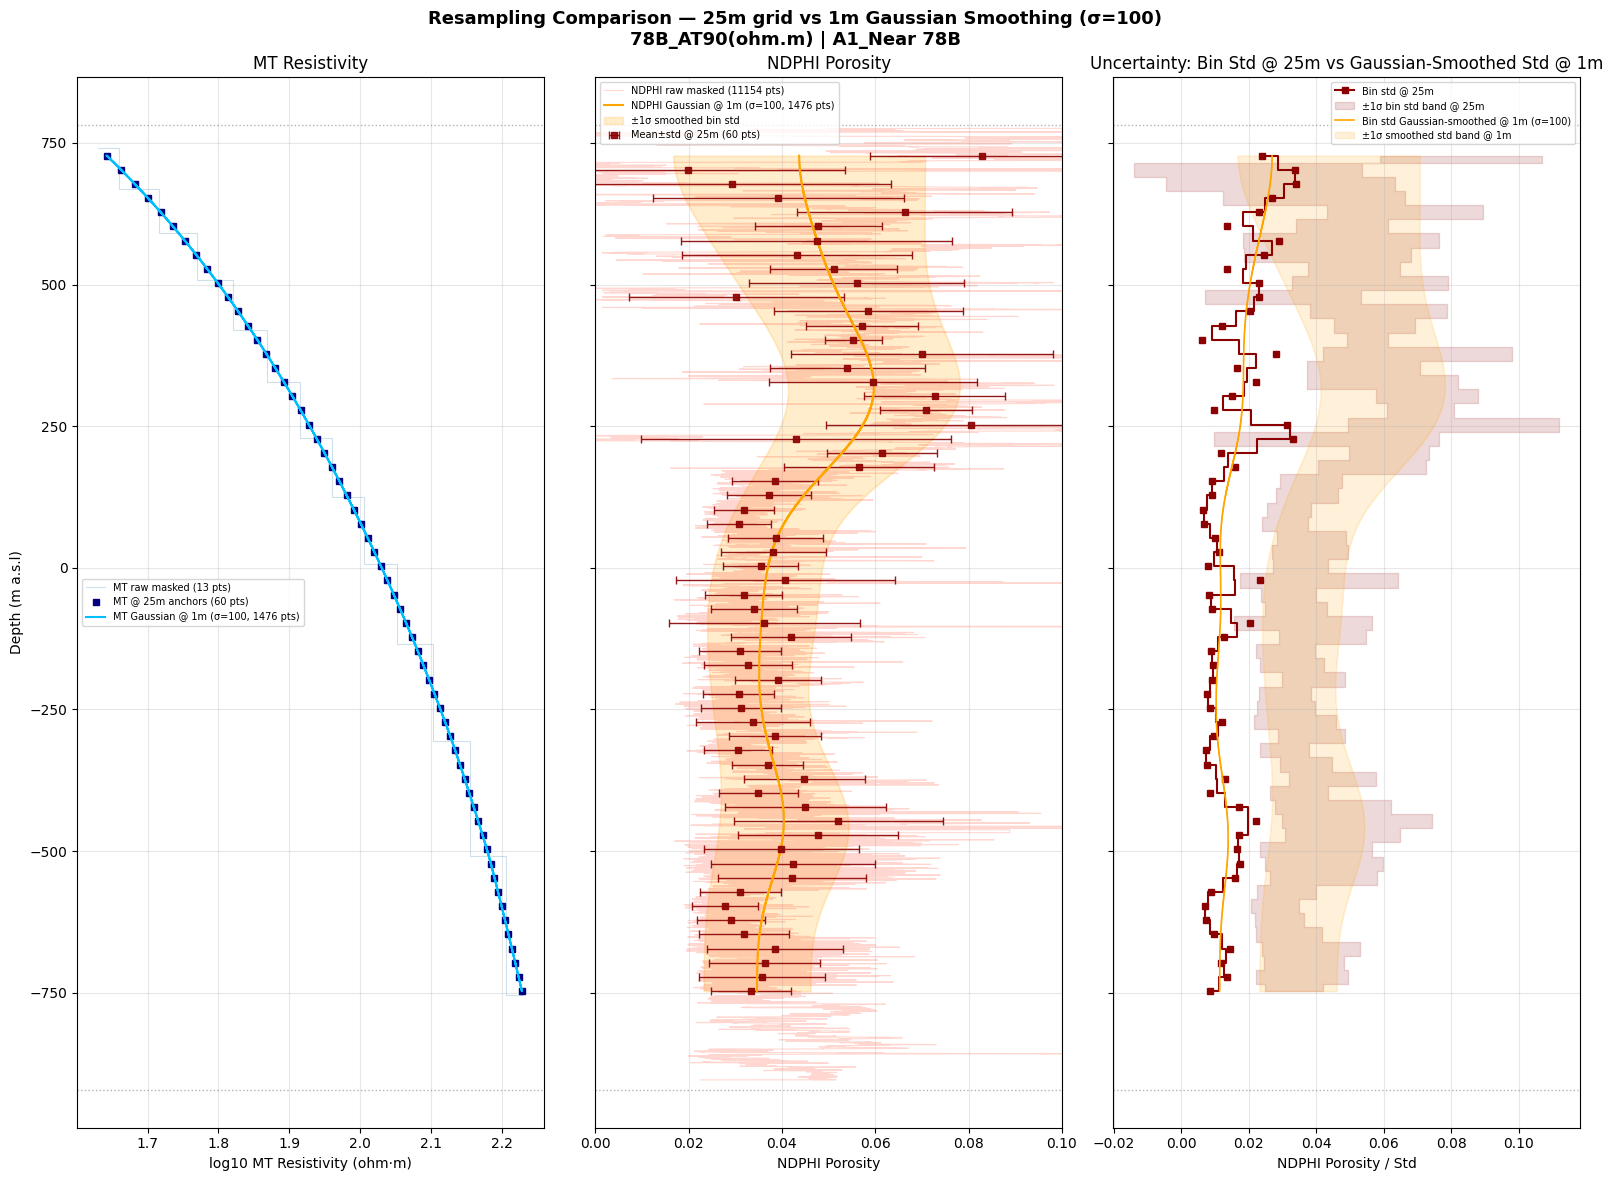

Saved: comparison_25m_vs_1m_Gaussian_78B_AT90(ohm.m).png


In [19]:
# ============== COMPARISON PLOT: 25m resampled vs 1m Gaussian Smoothed ==============

fig, axes = plt.subplots(1, 3, figsize=(16, 12), sharey=True)
fig.suptitle(f'Resampling Comparison — 25m grid vs 1m Gaussian Smoothing (σ={SIGMA})\n{well_name} | {mt_name}',
             fontsize=13, fontweight='bold')

STEP = 'steps-mid'

# ---------- Panel 1: MT Resistivity ----------
ax = axes[0]

# Raw MT (masked) — faded background reference
ax.plot(np.log10(mt_res_masked), mt_depth_masked,
        color='steelblue', lw=0.8, alpha=0.25, drawstyle=STEP,
        label=f'MT raw masked ({len(mt_depth_masked)} pts)')

# MT at 25m anchor points
ax.plot(np.log10(resampled_25m_clean['mt_res_ohmm']), resampled_25m_clean['depth_m'],
        color='navy', lw=0, drawstyle=STEP,
        marker='s', markersize=5, label=f'MT @ 25m anchors ({len(resampled_25m_clean)} pts)')

# MT Gaussian-smoothed 1m
ax.plot(np.log10(np.clip(resampled_1m_clean['mt_res_ohmm'], 1e-6, None)),
        resampled_1m_clean['depth_m'],
        color='deepskyblue', lw=1.5, drawstyle=STEP,
        label=f'MT Gaussian @ 1m (σ={SIGMA}, {len(resampled_1m_clean)} pts)')

ax.set_xlabel('log10 MT Resistivity (ohm·m)')
ax.set_ylabel('Depth (m a.s.l)')
ax.set_title('MT Resistivity')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ---------- Panel 2: NDPHI Porosity ----------
ax = axes[1]

# Raw NDPHI (masked) — faded background reference
ax.plot(ndphi_masked, ndphi_depth_masked,
        color='tomato', lw=0.8, alpha=0.25, drawstyle=STEP,
        label=f'NDPHI raw masked ({len(ndphi_depth_masked)} pts)')

# 25m anchor mean ± std (bin uncertainty)
ax.errorbar(resampled_25m_clean['ndphi_mean'], resampled_25m_clean['depth_m'],
            xerr=resampled_25m_clean['ndphi_std'],
            fmt='s', color='darkred', markersize=4, lw=1.2,
            capsize=3, elinewidth=1, alpha=0.9,
            label=f'Mean±std @ 25m ({len(resampled_25m_clean)} pts)')

# NDPHI Gaussian-smoothed 1m mean
ax.plot(resampled_1m_clean['ndphi_mean'], resampled_1m_clean['depth_m'],
        color='orange', lw=1.5, drawstyle=STEP,
        label=f'NDPHI Gaussian @ 1m (σ={SIGMA}, {len(resampled_1m_clean)} pts)')

# NDPHI ± smoothed bin std band
ax.fill_betweenx(resampled_1m_clean['depth_m'],
                 resampled_1m_clean['ndphi_mean'] - resampled_1m_clean['ndphi_std'],
                 resampled_1m_clean['ndphi_mean'] + resampled_1m_clean['ndphi_std'],
                 color='orange', alpha=0.2, step='mid',
                 label='±1σ smoothed bin std')

ax.set_xlim(0, 0.1)   # ← added
ax.set_xlabel('NDPHI Porosity')
ax.set_title('NDPHI Porosity')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ---------- Panel 3: Uncertainty — bin std @ 25m vs smoothed std @ 1m ----------
ax = axes[2]

# 25m bin std (original windowed uncertainty)
ax.plot(resampled_25m_clean['ndphi_std'], resampled_25m_clean['depth_m'],
        color='darkred', lw=1.5, drawstyle=STEP,
        marker='s', markersize=4, label='Bin std @ 25m')
ax.fill_betweenx(resampled_25m_clean['depth_m'],
                 resampled_25m_clean['ndphi_mean'] - resampled_25m_clean['ndphi_std'],
                 resampled_25m_clean['ndphi_mean'] + resampled_25m_clean['ndphi_std'],
                 color='darkred', alpha=0.15, step='mid', label='±1σ bin std band @ 25m')

# Gaussian-smoothed std at 1m
ax.plot(resampled_1m_clean['ndphi_std'], resampled_1m_clean['depth_m'],
        color='orange', lw=1.2, drawstyle=STEP,
        label=f'Bin std Gaussian-smoothed @ 1m (σ={SIGMA})')
ax.fill_betweenx(resampled_1m_clean['depth_m'],
                 resampled_1m_clean['ndphi_mean'] - resampled_1m_clean['ndphi_std'],
                 resampled_1m_clean['ndphi_mean'] + resampled_1m_clean['ndphi_std'],
                 color='orange', alpha=0.15, step='mid', label='±1σ smoothed std band @ 1m')

ax.set_xlabel('NDPHI Porosity / Std')
ax.set_title('Uncertainty: Bin Std @ 25m vs Gaussian-Smoothed Std @ 1m')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ---------- Common depth markers on all panels ----------
for ax in axes:
    ax.axhline(common_min, color='gray', lw=1, linestyle=':', alpha=0.6)
    ax.axhline(common_max, color='gray', lw=1, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(f'comparison_25m_vs_1m_Gaussian_{well_name}_78.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: comparison_25m_vs_1m_Gaussian_{well_name}.png")